<a href="https://colab.research.google.com/github/SagarEGme/AI-ML/blob/main/sagarEEG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)

# from scipy.signal import welch
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.signal import butter, filtfilt
# from scipy import stats
# from sklearn.preprocessing import LabelEncoder, StandardScaler
# from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
# from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# import warnings
# warnings.filterwarnings('ignore')

# # ============================================================================
# # DATA LOADING AND PREPROCESSING
# # ============================================================================

# individual = "/content/drive/MyDrive/minor_project/EEG_DATA/EEG_individual/"
# allData = "/content/drive/MyDrive/minor_project/EEG_DATA/EEG_all/BCICIV_all_patients.csv"

# lists = [allData]
# for i in range(1, 10):
#     readFrom = individual + 'BCICIV' + str(i) + '.csv'
#     lists.append(readFrom)

# df = pd.read_csv(lists[0])
# channels = ["EEG-C3", "EEG-Cz", "EEG-C4"]
# fs = 250

# def baseline_correct(group):
#     baseline = group[group["time"] < 0][channels].mean()
#     group[channels] = group[channels] - baseline
#     return group

# df_corrected = df.groupby(["patient", "epoch"], group_keys=False).apply(baseline_correct)

# def compute_psd_features(group):
#     features = {}
#     for ch in channels:
#         signal = group[ch].values
#         freqs, psd = welch(signal, fs=fs, nperseg=128)
#         mu_mask = (freqs >= 8) & (freqs <= 13)
#         mu_power = np.sum(psd[mu_mask])
#         features[f"{ch}_mu_power"] = mu_power
#     return pd.Series(features)

# psd_features_power = df_corrected.groupby(["patient", "epoch", "label"]).apply(compute_psd_features).reset_index()

# # Initial data cleaning using mu power heuristic
# df_predict = {}
# df_predict["Predict"] = np.where(psd_features_power['EEG-C4_mu_power'] > psd_features_power['EEG-C3_mu_power'], 'right', 'left')
# df_predict = pd.Series(df_predict)
# psd_features_power = psd_features_power[df_predict["Predict"] == psd_features_power["label"]]
# epochs = psd_features_power["epoch"]
# df_corrected = df_corrected[df_corrected["epoch"].isin(epochs)]

# # Create epochs array
# epoch_channels = ["EEG-C3", "EEG-Cz", "EEG-C4"]
# epochs_list = []
# labels = []

# for (_, group) in df_corrected.groupby(["patient", "epoch"]):
#     data = group[group["time"] >= 0][epoch_channels].values.T
#     if data.shape[1] == 176:
#         epochs_list.append(data)
#         labels.append(group["label"].iloc[0])

# X = np.array(epochs_list)
# y = np.array(labels)

# print(f"Initial epochs: {X.shape}")

# # Bandpass filter
# def bandpass(data, fs=250, low=8, high=30):
#     b, a = butter(4, [low/(fs/2), high/(fs/2)], btype='band')
#     return filtfilt(b, a, data, axis=2)

# X = bandpass(X)

# # Encode labels
# le = LabelEncoder()
# y = le.fit_transform(y)  # left=0, right=1

# # ============================================================================
# # ADAPTIVE ARTIFACT DETECTION (NO ICA)
# # ============================================================================

# class AdaptiveArtifactDetector:
#     def __init__(self, fs=250):
#         self.fs = fs
#         self.thresholds = {}

#     def fit(self, X):
#         # Calculate adaptive amplitude threshold (95th percentile)
#         all_ptp = []
#         for epoch in X:
#             ptp = epoch.max(axis=1) - epoch.min(axis=1)
#             all_ptp.extend(ptp)
#         all_ptp = np.array(all_ptp)
#         q75, q25 = np.percentile(all_ptp, [75, 25])
#         iqr = q75 - q25
#         self.thresholds['amplitude'] = q75 + 1.5 * iqr

#         # Calculate adaptive gradient threshold
#         all_gradients = []
#         for epoch in X:
#             gradient = np.diff(epoch, axis=1)
#             max_gradient = np.max(np.abs(gradient))
#             all_gradients.append(max_gradient)
#         self.thresholds['gradient'] = np.percentile(all_gradients, 95)

#         self.thresholds['kurtosis'] = 8

#         print(f"Adaptive thresholds:")
#         print(f"  Amplitude: {self.thresholds['amplitude']:.2f} µV")
#         print(f"  Gradient: {self.thresholds['gradient']:.2f} µV/sample")
#         return self

#     def detect_artifacts(self, X):
#         keep_indices = []
#         for i, epoch in enumerate(X):
#             # Amplitude check
#             ptp = epoch.max(axis=1) - epoch.min(axis=1)
#             amplitude_ok = ptp.max() <= self.thresholds['amplitude']

#             # Gradient check
#             gradient = np.diff(epoch, axis=1)
#             gradient_ok = np.max(np.abs(gradient)) <= self.thresholds['gradient']

#             # Kurtosis check
#             kurtosis_values = [stats.kurtosis(ch) for ch in epoch]
#             kurtosis_ok = np.max(kurtosis_values) <= self.thresholds['kurtosis']

#             # Keep if all checks pass
#             if amplitude_ok and gradient_ok and kurtosis_ok:
#                 keep_indices.append(i)

#         return np.array(keep_indices)

# # Apply artifact detection
# detector = AdaptiveArtifactDetector(fs=250)
# detector.fit(X)
# keep_indices = detector.detect_artifacts(X)

# print(f"\nArtifact Detection Results:")
# print(f"  Total epochs: {len(X)}")
# print(f"  Rejected: {len(X) - len(keep_indices)} ({100*(len(X)-len(keep_indices))/len(X):.1f}%)")
# print(f"  Remaining: {len(keep_indices)}")

# if len(keep_indices) == 0:
#     print("Using all epochs (no rejection)")
#     keep_indices = np.arange(len(X))

# X_clean = X[keep_indices]
# y_clean = y[keep_indices]


In [ ]:

# # ============================================================================
# # FEATURE ENGINEERING
# # ============================================================================

# def extract_time_domain_features(epoch):
#     """Extract time domain features from each channel"""
#     features = []
#     for channel in epoch:
#         features.extend([
#             np.mean(channel),           # Mean
#             np.std(channel),            # Standard deviation
#             np.max(channel) - np.min(channel),  # Peak-to-peak
#             np.sum(np.square(channel)), # Energy
#             np.mean(np.abs(channel)),   # Mean absolute value
#             stats.skew(channel),        # Skewness
#             stats.kurtosis(channel)     # Kurtosis
#         ])
#     return features

# def extract_frequency_features(epoch, fs=250):
#     """Extract frequency band powers"""
#     features = []
#     bands = {
#         'delta': (0.5, 4),
#         'theta': (4, 8),
#         'mu': (8, 13),
#         'beta': (13, 30),
#         'gamma': (30, 45)
#     }

#     for channel in epoch:
#         freqs, psd = welch(channel, fs=fs, nperseg=min(64, len(channel)))
#         for band_name, (low, high) in bands.items():
#             band_mask = (freqs >= low) & (freqs <= high)
#             if np.any(band_mask):
#                 band_power = np.sum(psd[band_mask])
#                 features.append(band_power)
#             else:
#                 features.append(0)

#     return features

# def extract_all_features(X):
#     """Extract all features from epochs"""
#     n_epochs = X.shape[0]
#     n_time_features = X.shape[1] * 7  # 7 time features per channel
#     n_freq_features = X.shape[1] * 5  # 5 frequency bands per channel

#     all_features = np.zeros((n_epochs, n_time_features + n_freq_features))

#     for i in range(n_epochs):
#         time_features = extract_time_domain_features(X[i])
#         freq_features = extract_frequency_features(X[i])
#         all_features[i] = np.concatenate([time_features, freq_features])

#     return all_features

# # Extract features
# print("\nExtracting features...")
# X_features = extract_all_features(X_clean)
# print(f"Feature shape: {X_features.shape}")

# # Normalize features
# scaler = StandardScaler()
# X_features_scaled = scaler.fit_transform(X_features)



In [ ]:
# # ============================================================================
# # DEEP LEARNING MODELS
# # ============================================================================

# import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras import layers, Model, Input
# from tensorflow.keras.utils import to_categorical
# from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# # Set random seeds for reproducibility
# tf.random.set_seed(42)
# np.random.seed(42)

# # Split data
# X_train, X_test, y_train, y_test = train_test_split(
#     X_features_scaled, y_clean, test_size=0.2, random_state=42, stratify=y_clean
# )

# # Convert labels to categorical for deep learning
# y_train_cat = to_categorical(y_train, 2)
# y_test_cat = to_categorical(y_test, 2)

# print(f"\nData split:")
# print(f"  Training: {X_train.shape[0]} samples")
# print(f"  Testing: {X_test.shape[0]} samples")

In [ ]:
# # ============================================================================
# # MODEL 1: DEEP NEURAL NETWORK
# # ============================================================================

# def create_dnn(input_dim):
#     model = keras.Sequential([
#         layers.Input(shape=(input_dim,)),
#         layers.Dense(128, activation='relu'),
#         layers.BatchNormalization(),
#         layers.Dropout(0.3),

#         layers.Dense(64, activation='relu'),
#         layers.BatchNormalization(),
#         layers.Dropout(0.3),

#         layers.Dense(32, activation='relu'),
#         layers.BatchNormalization(),
#         layers.Dropout(0.2),

#         layers.Dense(2, activation='softmax')
#     ])

#     model.compile(
#         optimizer=keras.optimizers.Adam(learning_rate=0.001),
#         loss='categorical_crossentropy',
#         metrics=['accuracy']
#     )

#     return model

# # Create and train DNN
# print("\n" + "="*60)
# print("MODEL 1: Deep Neural Network")
# print("="*60)

# dnn_model = create_dnn(X_train.shape[1])
# dnn_model.summary()

# callbacks = [
#     EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
#     ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
# ]

# history_dnn = dnn_model.fit(
#     X_train, y_train_cat,
#     validation_split=0.2,
#     epochs=100,
#     batch_size=32,
#     callbacks=callbacks,
#     verbose=1
# )

# # Evaluate DNN
# y_pred_dnn = np.argmax(dnn_model.predict(X_test), axis=1)
# accuracy_dnn = accuracy_score(y_test, y_pred_dnn)

# print(f"\nDNN Test Accuracy: {accuracy_dnn:.4f}")
# print("\nClassification Report:")
# print(classification_report(y_test, y_pred_dnn, target_names=['Left', 'Right']))


In [ ]:
# # ============================================================================
# # MODEL 2: CONVOLUTIONAL NEURAL NETWORK (on raw EEG)
# # ============================================================================

# def create_cnn(input_shape):
#     model = keras.Sequential([
#         layers.Input(shape=input_shape),

#         # Conv1D layers for temporal features
#         layers.Conv1D(filters=64, kernel_size=5, activation='relu', padding='same'),
#         layers.BatchNormalization(),
#         layers.MaxPooling1D(pool_size=2),
#         layers.Dropout(0.3),

#         layers.Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
#         layers.BatchNormalization(),
#         layers.MaxPooling1D(pool_size=2),
#         layers.Dropout(0.3),

#         layers.Conv1D(filters=256, kernel_size=3, activation='relu', padding='same'),
#         layers.BatchNormalization(),
#         layers.GlobalAveragePooling1D(),
#         layers.Dropout(0.4),

#         layers.Dense(64, activation='relu'),
#         layers.BatchNormalization(),
#         layers.Dropout(0.3),

#         layers.Dense(2, activation='softmax')
#     ])

#     model.compile(
#         optimizer=keras.optimizers.Adam(learning_rate=0.001),
#         loss='categorical_crossentropy',
#         metrics=['accuracy']
#     )

#     return model

# # Prepare raw EEG data for CNN (shape: samples, time, channels)
# X_raw = X_clean.transpose(0, 2, 1)  # (n_epochs, n_samples, n_channels)
# X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
#     X_raw, y_clean, test_size=0.2, random_state=42, stratify=y_clean
# )

# y_train_raw_cat = to_categorical(y_train_raw, 2)
# y_test_raw_cat = to_categorical(y_test_raw, 2)

# print("\n" + "="*60)
# print("MODEL 2: 1D Convolutional Neural Network (on raw EEG)")
# print("="*60)

# cnn_model = create_cnn((X_train_raw.shape[1], X_train_raw.shape[2]))
# cnn_model.summary()

# history_cnn = cnn_model.fit(
#     X_train_raw, y_train_raw_cat,
#     validation_split=0.2,
#     epochs=100,
#     batch_size=32,
#     callbacks=callbacks,
#     verbose=1
# )

# # Evaluate CNN
# y_pred_cnn = np.argmax(cnn_model.predict(X_test_raw), axis=1)
# accuracy_cnn = accuracy_score(y_test_raw, y_pred_cnn)

# print(f"\nCNN Test Accuracy: {accuracy_cnn:.4f}")
# print("\nClassification Report:")
# print(classification_report(y_test_raw, y_pred_cnn, target_names=['Left', 'Right']))


In [ ]:

# # ============================================================================
# # MODEL 3: EEGNet (Specialized for EEG)
# # ============================================================================

# def create_eegnet(n_channels=3, n_samples=176, n_classes=2):
#     """EEGNet architecture for motor imagery classification"""

#     input_layer = layers.Input(shape=(n_channels, n_samples, 1))

#     # Block 1: Temporal convolution
#     block1 = layers.Conv2D(8, (1, 64), padding='same', use_bias=False)(input_layer)
#     block1 = layers.BatchNormalization()(block1)
#     block1 = layers.DepthwiseConv2D((n_channels, 1), use_bias=False, depth_multiplier=2)(block1)
#     block1 = layers.BatchNormalization()(block1)
#     block1 = layers.Activation('elu')(block1)
#     block1 = layers.AveragePooling2D((1, 4))(block1)
#     block1 = layers.Dropout(0.25)(block1)

#     # Block 2: Separable convolution
#     block2 = layers.SeparableConv2D(16, (1, 16), use_bias=False, padding='same')(block1)
#     block2 = layers.BatchNormalization()(block2)
#     block2 = layers.Activation('elu')(block2)
#     block2 = layers.AveragePooling2D((1, 8))(block2)
#     block2 = layers.Dropout(0.25)(block2)

#     # Classification
#     flatten = layers.Flatten()(block2)
#     dense = layers.Dense(n_classes, activation='softmax')(flatten)

#     model = Model(inputs=input_layer, outputs=dense)

#     model.compile(
#         optimizer=keras.optimizers.Adam(learning_rate=0.001),
#         loss='categorical_crossentropy',
#         metrics=['accuracy']
#     )

#     return model

# # Prepare data for EEGNet (shape: samples, channels, time, 1)
# X_eegnet = X_clean[:, :, :, np.newaxis]  # (n_epochs, n_channels, n_samples, 1)
# X_train_eegnet, X_test_eegnet, y_train_eegnet, y_test_eegnet = train_test_split(
#     X_eegnet, y_clean, test_size=0.2, random_state=42, stratify=y_clean
# )

# y_train_eegnet_cat = to_categorical(y_train_eegnet, 2)
# y_test_eegnet_cat = to_categorical(y_test_eegnet, 2)

# print("\n" + "="*60)
# print("MODEL 3: EEGNet (Specialized for EEG)")
# print("="*60)

# eegnet_model = create_eegnet(n_channels=3, n_samples=176, n_classes=2)
# eegnet_model.summary()

# history_eegnet = eegnet_model.fit(
#     X_train_eegnet, y_train_eegnet_cat,
#     validation_split=0.2,
#     epochs=100,
#     batch_size=32,
#     callbacks=callbacks,
#     verbose=1
# )

# # Evaluate EEGNet
# y_pred_eegnet = np.argmax(eegnet_model.predict(X_test_eegnet), axis=1)
# accuracy_eegnet = accuracy_score(y_test_eegnet, y_pred_eegnet)

# print(f"\nEEGNet Test Accuracy: {accuracy_eegnet:.4f}")
# print("\nClassification Report:")
# print(classification_report(y_test_eegnet, y_pred_eegnet, target_names=['Left', 'Right']))



In [ ]:
# # ============================================================================
# # MODEL 4: LSTM for Temporal Sequence
# # ============================================================================

# def create_lstm(input_shape):
#     model = keras.Sequential([
#         layers.Input(shape=input_shape),

#         layers.LSTM(64, return_sequences=True),
#         layers.Dropout(0.3),

#         layers.LSTM(32, return_sequences=False),
#         layers.Dropout(0.3),

#         layers.Dense(32, activation='relu'),
#         layers.BatchNormalization(),
#         layers.Dropout(0.3),

#         layers.Dense(2, activation='softmax')
#     ])

#     model.compile(
#         optimizer=keras.optimizers.Adam(learning_rate=0.001),
#         loss='categorical_crossentropy',
#         metrics=['accuracy']
#     )

#     return model

# # Prepare data for LSTM (samples, time_steps, features)
# X_lstm = X_clean.transpose(0, 2, 1)  # (n_epochs, n_samples, n_channels)
# X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(
#     X_lstm, y_clean, test_size=0.2, random_state=42, stratify=y_clean
# )

# y_train_lstm_cat = to_categorical(y_train_lstm, 2)
# y_test_lstm_cat = to_categorical(y_test_lstm, 2)

# print("\n" + "="*60)
# print("MODEL 4: LSTM Network")
# print("="*60)

# lstm_model = create_lstm((X_train_lstm.shape[1], X_train_lstm.shape[2]))
# lstm_model.summary()

# history_lstm = lstm_model.fit(
#     X_train_lstm, y_train_lstm_cat,
#     validation_split=0.2,
#     epochs=100,
#     batch_size=32,
#     callbacks=callbacks,
#     verbose=1
# )

# # Evaluate LSTM
# y_pred_lstm = np.argmax(lstm_model.predict(X_test_lstm), axis=1)
# accuracy_lstm = accuracy_score(y_test_lstm, y_pred_lstm)

# print(f"\nLSTM Test Accuracy: {accuracy_lstm:.4f}")
# print("\nClassification Report:")
# print(classification_report(y_test_lstm, y_pred_lstm, target_names=['Left', 'Right']))

In [ ]:

# # ============================================================================
# # MODEL COMPARISON AND VISUALIZATION
# # ============================================================================

# # Compile results
# results = {
#     'DNN': accuracy_dnn,
#     'CNN (1D)': accuracy_cnn,
#     'EEGNet': accuracy_eegnet,
#     'LSTM': accuracy_lstm
# }

# print("\n" + "="*60)
# print("MODEL COMPARISON SUMMARY")
# print("="*60)
# for model_name, acc in results.items():
#     print(f"{model_name:12} : {acc:.4f} ({acc*100:.2f}%)")

# best_model = max(results, key=results.get)
# print(f"\n🏆 Best Model: {best_model} with {results[best_model]*100:.2f}% accuracy")

In [ ]:
# # Plot training histories
# fig, axes = plt.subplots(2, 2, figsize=(15, 10))
# models_histories = [history_dnn, history_cnn, history_eegnet, history_lstm]
# model_names = ['DNN', 'CNN', 'EEGNet', 'LSTM']

# for idx, (hist, name) in enumerate(zip(models_histories, model_names)):
#     row, col = idx // 2, idx % 2
#     axes[row, col].plot(hist.history['accuracy'], label='Train')
#     axes[row, col].plot(hist.history['val_accuracy'], label='Validation')
#     axes[row, col].set_title(f'{name} - Accuracy')
#     axes[row, col].set_xlabel('Epoch')
#     axes[row, col].set_ylabel('Accuracy')
#     axes[row, col].legend()
#     axes[row, col].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

In [ ]:
# # Plot comparison bar chart
# plt.figure(figsize=(10, 6))
# models = list(results.keys())
# accuracies = list(results.values())
# bars = plt.bar(models, accuracies, color=['blue', 'green', 'red', 'purple'])
# plt.axhline(y=0.5, color='gray', linestyle='--', label='Chance Level')
# plt.xlabel('Model')
# plt.ylabel('Accuracy')
# plt.title('Model Performance Comparison')
# plt.ylim(0, 1)
# for bar, acc in zip(bars, accuracies):
#     plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
#              f'{acc:.3f}', ha='center', va='bottom')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()

In [ ]:
# # Confusion matrices for all models
# fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# predictions = [y_pred_dnn, y_pred_cnn, y_pred_eegnet, y_pred_lstm]

# for idx, (model_name, pred) in enumerate(zip(model_names, predictions)):
#     row, col = idx // 2, idx % 2
#     cm = confusion_matrix(y_test, pred)
#     im = axes[row, col].imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
#     axes[row, col].set_title(f'{model_name} - Confusion Matrix')
#     axes[row, col].set_xlabel('Predicted')
#     axes[row, col].set_ylabel('True')
#     axes[row, col].set_xticks([0, 1])
#     axes[row, col].set_yticks([0, 1])
#     axes[row, col].set_xticklabels(['Left', 'Right'])
#     axes[row, col].set_yticklabels(['Left', 'Right'])

#     # Add text annotations
#     for i in range(2):
#         for j in range(2):
#             axes[row, col].text(j, i, cm[i, j], ha='center', va='center', color='white' if cm[i, j] > cm.max()/2 else 'black')

# plt.tight_layout()
# plt.show()

In [ ]:
# from scipy.signal import welch
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.signal import butter, filtfilt
# from scipy import stats
# from sklearn.preprocessing import LabelEncoder, StandardScaler
# from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
# from sklearn.svm import SVC
# from sklearn.linear_model import LogisticRegression
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.naive_bayes import GaussianNB
# from xgboost import XGBClassifier
# from lightgbm import LGBMClassifier
# import warnings
# warnings.filterwarnings('ignore')


# # ============================================================================
# # CLASSICAL ML MODELS
# # ============================================================================

# # Define all classical ML models
# models = {
#     'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
#     'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
#     'Decision Tree': DecisionTreeClassifier(random_state=42),
#     'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
#     'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
#     'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
#     'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42),
#     'SVM (Linear)': SVC(kernel='linear', probability=True, random_state=42),
#     'Gaussian NB': GaussianNB(),
#     'XGBoost': XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss'),
#     'LightGBM': LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
# }

# # ============================================================================
# # TRAIN AND EVALUATE MODELS
# # ============================================================================

# print("\n" + "="*70)
# print("CLASSICAL ML MODELS PERFORMANCE")
# print("="*70)

# results = {}
# cv_scores = {}

# for name, model in models.items():
#     print(f"\n{name}:")
#     print("-" * 50)

#     # Train model
#     model.fit(X_train, y_train)

#     # Predict on test set
#     y_pred = model.predict(X_test)

#     # Calculate accuracy
#     acc = accuracy_score(y_test, y_pred)
#     results[name] = acc

#     # Cross-validation
#     cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
#     cv_score = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
#     cv_scores[name] = cv_score

#     print(f"Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")
#     print(f"CV Accuracy: {cv_score.mean():.4f} (±{cv_score.std():.4f})")
#     print(f"\nClassification Report:")
#     print(classification_report(y_test, y_pred, target_names=['Left', 'Right']))

# # ============================================================================
# # RESULTS VISUALIZATION
# # ============================================================================

# # Sort models by accuracy
# sorted_models = sorted(results.items(), key=lambda x: x[1], reverse=True)

# print("\n" + "="*70)
# print("MODEL RANKING (by Test Accuracy)")
# print("="*70)
# for i, (name, acc) in enumerate(sorted_models, 1):
#     print(f"{i}. {name:25} : {acc:.4f} ({acc*100:.2f}%)")

# # Plot results
# plt.figure(figsize=(14, 8))
# model_names = list(results.keys())
# accuracies = list(results.values())
# cv_means = [cv_scores[name].mean() for name in model_names]
# cv_stds = [cv_scores[name].std() for name in model_names]

# # Sort for better visualization
# sorted_indices = np.argsort(accuracies)[::-1]
# model_names_sorted = [model_names[i] for i in sorted_indices]
# accuracies_sorted = [accuracies[i] for i in sorted_indices]
# cv_means_sorted = [cv_means[i] for i in sorted_indices]
# cv_stds_sorted = [cv_stds[i] for i in sorted_indices]

# x = np.arange(len(model_names_sorted))
# width = 0.35

# fig, ax = plt.subplots(figsize=(14, 8))
# bars1 = ax.bar(x - width/2, accuracies_sorted, width, label='Test Accuracy', color='skyblue')
# bars2 = ax.bar(x + width/2, cv_means_sorted, width, label='CV Accuracy', color='lightgreen',
#                yerr=cv_stds_sorted, capsize=5)

# ax.set_xlabel('Models')
# ax.set_ylabel('Accuracy')
# ax.set_title('Classical ML Models Performance Comparison')
# ax.set_xticks(x)
# ax.set_xticklabels(model_names_sorted, rotation=45, ha='right')
# ax.axhline(y=0.5, color='red', linestyle='--', label='Chance Level', alpha=0.7)
# ax.legend()
# ax.grid(True, alpha=0.3)

# # Add value labels on bars
# for bar in bars1:
#     height = bar.get_height()
#     ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
#             f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# for bar in bars2:
#     height = bar.get_height()
#     ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
#             f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# plt.tight_layout()
# plt.show()

# # Confusion matrices for top 5 models
# top_5_models = sorted_models[:5]
# fig, axes = plt.subplots(2, 3, figsize=(15, 10))
# axes = axes.flatten()

# for idx, (name, _) in enumerate(top_5_models):
#     model = models[name]
#     y_pred = model.predict(X_test)
#     cm = confusion_matrix(y_test, y_pred)

#     axes[idx].imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
#     axes[idx].set_title(f'{name}\nAccuracy: {results[name]:.3f}')
#     axes[idx].set_xlabel('Predicted')
#     axes[idx].set_ylabel('True')
#     axes[idx].set_xticks([0, 1])
#     axes[idx].set_yticks([0, 1])
#     axes[idx].set_xticklabels(['Left', 'Right'])
#     axes[idx].set_yticklabels(['Left', 'Right'])

#     # Add text annotations
#     for i in range(2):
#         for j in range(2):
#             axes[idx].text(j, i, cm[i, j], ha='center', va='center',
#                           color='white' if cm[i, j] > cm.max()/2 else 'black')

# # Remove empty subplot
# if len(top_5_models) < 6:
#     fig.delaxes(axes[5])

# plt.tight_layout()
# plt.show()

# # ============================================================================
# # FEATURE IMPORTANCE (For tree-based models)
# # ============================================================================

# print("\n" + "="*70)
# print("FEATURE IMPORTANCE (Random Forest)")
# print("="*70)

# rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
# rf_model.fit(X_train, y_train)

# feature_importance = rf_model.feature_importances_
# top_20_indices = np.argsort(feature_importance)[-20:]

# plt.figure(figsize=(10, 6))
# plt.barh(range(20), feature_importance[top_20_indices])
# plt.yticks(range(20), [f'Feature {i}' for i in top_20_indices])
# plt.xlabel('Importance')
# plt.title('Top 20 Most Important Features (Random Forest)')
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

# # ============================================================================
# # BEST MODEL DETAILED ANALYSIS
# # ============================================================================

# best_model_name = sorted_models[0][0]
# best_model = models[best_model_name]
# best_accuracy = sorted_models[0][1]

# print("\n" + "="*70)
# print(f"BEST MODEL: {best_model_name}")
# print("="*70)
# print(f"Test Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
# print(f"CV Accuracy: {cv_scores[best_model_name].mean():.4f} (±{cv_scores[best_model_name].std():.4f})")

# # Train on full training data and evaluate
# best_model.fit(X_train, y_train)
# y_pred_best = best_model.predict(X_test)

# print("\nDetailed Classification Report:")
# print(classification_report(y_test, y_pred_best, target_names=['Left', 'Right']))

# print("\nConfusion Matrix:")
# cm_best = confusion_matrix(y_test, y_pred_best)
# print(cm_best)

# # Calculate additional metrics
# tn, fp, fn, tp = cm_best.ravel()
# sensitivity = tp / (tp + fn)
# specificity = tn / (tn + fp)
# print(f"\nSensitivity (Recall - Right): {sensitivity:.4f}")
# print(f"Specificity (Recall - Left): {specificity:.4f}")
# print(f"Balanced Accuracy: {(sensitivity + specificity)/2:.4f}")

In [ ]:
pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00


In [ ]:
# CHUNK 1: Setup and Data Loading
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


from scipy.signal import welch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
np.random.seed(42)

print("✅ Chunk 1: Libraries loaded successfully")

Mounted at /content/drive
✅ Chunk 1: Libraries loaded successfully


In [ ]:
individual = "/content/drive/MyDrive/minor_project/EEG_DATA/EEG_individual/"
allData = "/content/drive/MyDrive/minor_project/EEG_DATA/EEG_all/BCICIV_all_patients.csv"

lists = [allData]
for i in range(1, 10):
    readFrom = individual + 'BCICIV' + str(i) + '.csv'
    lists.append(readFrom)

df = pd.read_csv(lists[0])
df.head()

,patient,time,label,epoch,EEG-C3,EEG-Cz,EEG-C4
0,1,-0.100,right,12,-4.680500,3.699157,4.052222
1,1,-0.096,right,12,-3.757205,0.960343,1.362236
2,1,-0.092,right,12,-0.587816,-0.215971,-1.523062
3,1,-0.088,right,12,2.943346,-0.298091,-3.655963
4,1,-0.084,right,12,4.417067,-0.777494,-5.160757


In [ ]:
# CHUNK 2: Data Loading and Preprocessing

channels = ["EEG-C3", "EEG-Cz", "EEG-C4"]
fs = 250

def baseline_correct(group):
    baseline = group[group["time"] < 0][channels].mean()
    group[channels] = group[channels] - baseline
    return group

df_corrected = df.groupby(["patient", "epoch"], group_keys=False).apply(baseline_correct)

def compute_psd_features(group):
    features = {}
    for ch in channels:
        signal = group[ch].values
        freqs, psd = welch(signal, fs=fs, nperseg=128)
        mu_mask = (freqs >= 8) & (freqs <= 13)
        mu_power = np.sum(psd[mu_mask])
        features[f"{ch}_mu_power"] = mu_power
    return pd.Series(features)

psd_features_power = df_corrected.groupby(["patient", "epoch", "label"]).apply(compute_psd_features).reset_index()

# Initial data cleaning
df_predict = {}
df_predict["Predict"] = np.where(psd_features_power['EEG-C4_mu_power'] > psd_features_power['EEG-C3_mu_power'], 'right', 'left')
df_predict = pd.Series(df_predict)
psd_features_power = psd_features_power[df_predict["Predict"] == psd_features_power["label"]]
epochs = psd_features_power["epoch"]
df_corrected1 = df_corrected[df_corrected["epoch"].isin(epochs)]

# Create epochs
epoch_channels = ["EEG-C3", "EEG-Cz", "EEG-C4"]
epochs_list = []
labels = []
patients_list = []

for (patient, group) in df_corrected.groupby(["patient", "epoch"]):
    data = group[group["time"] >= 0][epoch_channels].values.T
    if data.shape[1] == 176:
        epochs_list.append(data)
        labels.append(group["label"].iloc[0])
        patients_list.append(patient[0])

X = np.array(epochs_list)
print("x is ", X)
y = np.array(labels)
patients = np.array(patients_list)

print(f"✅ Data loaded: {X.shape[0]} epochs, {X.shape[1]} channels, {X.shape[2]} time points")
print(f"✅ Patients: {np.unique(patients)}")
print(f"✅ Class distribution: Left={np.sum(y=='left')}, Right={np.sum(y=='right')}")

x is  [[[ 1.15909091e+00  1.19682173e+00  2.39754972e+00 ... -2.30770597e+00
   -2.05246804e+00 -3.34863281e+00]
  [ 6.37002841e+00  3.81986861e+00  3.75106534e+00 ...  3.68448153e+00
    2.86550071e+00  1.76464844e+00]
  [-4.18075284e+00 -8.29341264e+00 -8.26455966e+00 ... -1.28018466e-01
    2.66628196e+00  1.27246094e+00]]

 [[ 5.68270597e-01  2.99636009e+00  1.62473366e+00 ... -4.65411932e+00
   -4.45658736e+00 -1.93084162e+00]
  [ 2.90420810e+00  4.11159446e+00  5.42702415e-01 ...  1.24627131e+00
    1.63911577e+00  1.82111151e+00]
  [-6.06356534e-02  2.67844460e-01 -1.54323509e+00 ...  4.67791193e+00
    4.87544389e+00  2.37189276e+00]]

 [[-7.33540483e+00 -6.48091264e+00 -2.51029830e+00 ... -2.47256747e+00
    1.42036577e+00  2.24378551e+00]
  [-5.18501420e+00 -5.30708452e+00 -4.80326705e+00 ... -1.17479581e+01
   -1.09311967e+01 -1.08401989e+01]
  [ 4.98295455e+00  2.85893111e+00  1.75142045e+00 ... -1.48233310e+00
   -3.15580611e+00 -2.82066761e+00]]

 ...

 [[-6.62730824e-01 

In [ ]:
# CHUNK 3: Signal Filtering
def bandpass(data, fs=250, low=8, high=30):
    b, a = butter(4, [low/(fs/2), high/(fs/2)], btype='band')
    return filtfilt(b, a, data, axis=2)

X = bandpass(X)

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y)  # left=0, right=1

print(f"✅ Signal filtered (8-30 Hz)")
print(f"✅ Labels encoded: {dict(zip(le.classes_, le.transform(le.classes_)))}")

✅ Signal filtered (8-30 Hz)
✅ Labels encoded: {np.str_('left'): np.int64(0), np.str_('right'): np.int64(1)}


In [ ]:
# CHUNK 4: Enhanced Feature Extraction
def extract_advanced_features(epoch, fs=250):
    """Extract comprehensive features for better classification"""
    features = []
    n_channels = epoch.shape[0]
    n_samples = epoch.shape[1]

    for ch_idx in range(n_channels):
        signal = epoch[ch_idx]

        # 1. Statistical features
        features.extend([
            np.mean(signal),           # Mean
            np.std(signal),            # Standard deviation
            np.var(signal),            # Variance
            stats.skew(signal),        # Skewness
            stats.kurtosis(signal),    # Kurtosis
            np.median(signal),         # Median
            np.percentile(signal, 25), # Q1
            np.percentile(signal, 75), # Q3
            np.max(signal),            # Max
            np.min(signal),            # Min
            np.max(signal) - np.min(signal),  # Peak-to-peak
            np.sum(np.square(signal)), # Energy
            np.sum(np.abs(signal)),    # Absolute energy
            np.mean(np.abs(np.diff(signal))),  # Mean absolute derivative
            np.std(np.diff(signal)),   # Std of derivative
        ])

        # 2. Frequency band powers
        freqs, psd = welch(signal, fs=fs, nperseg=min(64, len(signal)))

        bands = {
            'delta': (0.5, 4),
            'theta': (4, 8),
            'alpha': (8, 12),
            'mu': (8, 13),
            'beta_low': (13, 20),
            'beta_high': (20, 30),
            'gamma': (30, 45)
        }

        for band_name, (low, high) in bands.items():
            band_mask = (freqs >= low) & (freqs <= high)
            if np.any(band_mask):
                band_power = np.sum(psd[band_mask])
                features.append(band_power)
                # Add relative power
                features.append(band_power / np.sum(psd))
            else:
                features.extend([0, 0])

        # 3. Spectral edge frequencies
        cumsum = np.cumsum(psd)
        total_power = cumsum[-1]
        if total_power > 0:
            sef_50 = freqs[np.where(cumsum >= 0.5 * total_power)[0][0]] if len(np.where(cumsum >= 0.5 * total_power)[0]) > 0 else 0
            sef_95 = freqs[np.where(cumsum >= 0.95 * total_power)[0][0]] if len(np.where(cumsum >= 0.95 * total_power)[0]) > 0 else 0
            features.extend([sef_50, sef_95])
        else:
            features.extend([0, 0])

    # 4. Cross-channel features
    for i in range(n_channels):
        for j in range(i+1, n_channels):
            # Pearson correlation
            corr = np.corrcoef(epoch[i], epoch[j])[0, 1]
            features.append(corr)

            # Coherence at mu band (8-13 Hz)
            freqs, Cxy = plt.mlab.cohere(epoch[i], epoch[j], NFFT=64, Fs=fs)
            mu_mask = (freqs >= 8) & (freqs <= 13)
            if np.any(mu_mask):
                coherence_mu = np.mean(Cxy[mu_mask])
                features.append(coherence_mu)
            else:
                features.append(0)

    return np.array(features)

# Extract features
print("Extracting features...")
X_features = []
for i in range(len(X)):
    if i % 200 == 0:
        print(f"  Processed {i}/{len(X)} epochs")
    features = extract_advanced_features(X[i])
    X_features.append(features)

X_features = np.array(X_features)
print(f"✅ Feature extraction complete: {X_features.shape}")

In [ ]:
# CHUNK 5: Feature Selection and Dimensionality Reduction
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.decomposition import PCA

# Normalize features
scaler = RobustScaler()
X_features_scaled = scaler.fit_transform(X_features)

# Feature selection using mutual information
print("Performing feature selection...")
selector = SelectKBest(mutual_info_classif, k=min(100, X_features_scaled.shape[1]))
X_features_selected = selector.fit_transform(X_features_scaled, y)

print(f"✅ Features reduced from {X_features_scaled.shape[1]} to {X_features_selected.shape[1]}")

# Optional: Apply PCA for further reduction
pca = PCA(n_components=0.95)  # Keep 95% variance
X_features_pca = pca.fit_transform(X_features_selected)

print(f"✅ PCA reduced to {X_features_pca.shape[1]} components explaining {pca.explained_variance_ratio_.sum():.2%} variance")

# Use the best performing feature set (try both)
X_final = X_features_pca  # Using PCA features
print(f"✅ Final feature set shape: {X_final.shape}")

In [ ]:
# CHUNK 6: Train-Test Split
# Patient-wise split to avoid data leakage
unique_patients = np.unique(patients)
n_train_patients = int(0.8 * len(unique_patients))
train_patients = unique_patients[:n_train_patients]
test_patients = unique_patients[n_train_patients:]

train_mask = np.isin(patients, train_patients)
test_mask = np.isin(patients, test_patients)

X_train = X_final[train_mask]
X_test = X_final[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

print(f"✅ Patient-wise split:")
print(f"  Training patients: {train_patients}")
print(f"  Testing patients: {test_patients}")
print(f"  Training samples: {len(X_train)}")
print(f"  Testing samples: {len(X_test)}")
print(f"  Class distribution - Train: {np.bincount(y_train)}")
print(f"  Class distribution - Test: {np.bincount(y_test)}")

In [ ]:
# CHUNK 7: Hyperparameter Tuning for AdaBoost
from sklearn.model_selection import GridSearchCV

print("="*70)
print("Tuning AdaBoost Hyperparameters")
print("="*70)

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0],
    'algorithm': ['SAMME', 'SAMME.R']
}

# Base estimator options
base_estimators = {
    'Decision Tree (depth 1)': DecisionTreeClassifier(max_depth=1),
    'Decision Tree (depth 2)': DecisionTreeClassifier(max_depth=2),
    'Decision Tree (depth 3)': DecisionTreeClassifier(max_depth=3),
}

best_ada_params = {}
best_ada_score = 0
best_ada_base = None

for base_name, base_est in base_estimators.items():
    print(f"\nTuning with base estimator: {base_name}")

    ada = AdaBoostClassifier(estimator=base_est, random_state=42)

    grid_search = GridSearchCV(
        ada, param_grid,
        cv=StratifiedKFold(5, shuffle=True, random_state=42),
        scoring='accuracy',
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train, y_train)

    print(f"  Best parameters: {grid_search.best_params_}")
    print(f"  Best CV score: {grid_search.best_score_:.4f}")

    if grid_search.best_score_ > best_ada_score:
        best_ada_score = grid_search.best_score_
        best_ada_params = grid_search.best_params_
        best_ada_base = base_name
        best_ada_model = grid_search.best_estimator_

print(f"\n✅ Best AdaBoost configuration:")
print(f"  Base estimator: {best_ada_base}")
print(f"  Parameters: {best_ada_params}")
print(f"  CV Score: {best_ada_score:.4f}")

Tuning AdaBoost Hyperparameters

Tuning with base estimator: Decision Tree (depth 1)
Fitting 5 folds for each of 40 candidates, totalling 200 fits
  Best parameters: {'algorithm': 'SAMME', 'learning_rate': 0.5, 'n_estimators': 200}
  Best CV score: 0.5744

Tuning with base estimator: Decision Tree (depth 2)
Fitting 5 folds for each of 40 candidates, totalling 200 fits
  Best parameters: {'algorithm': 'SAMME', 'learning_rate': 0.5, 'n_estimators': 50}
  Best CV score: 0.5725

Tuning with base estimator: Decision Tree (depth 3)
Fitting 5 folds for each of 40 candidates, totalling 200 fits
  Best parameters: {'algorithm': 'SAMME', 'learning_rate': 0.5, 'n_estimators': 100}
  Best CV score: 0.5635

✅ Best AdaBoost configuration:
  Base estimator: Decision Tree (depth 1)
  Parameters: {'algorithm': 'SAMME', 'learning_rate': 0.5, 'n_estimators': 200}
  CV Score: 0.5744


In [ ]:
# CHUNK 8: Train Multiple Optimized Models
print("="*70)
print("Training Optimized Models")
print("="*70)

# 1. Optimized AdaBoost
print("\n1. Training Optimized AdaBoost...")
ada_optimized = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=best_ada_params.get('n_estimators', 150),
    learning_rate=best_ada_params.get('learning_rate', 0.5),
    algorithm=best_ada_params.get('algorithm', 'SAMME.R'),
    random_state=42
)
ada_optimized.fit(X_train, y_train)

# 2. Gradient Boosting with tuned parameters
print("\n2. Training Optimized Gradient Boosting...")
gb_optimized = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=3,
    subsample=0.8,
    random_state=42
)
gb_optimized.fit(X_train, y_train)

# 3. XGBoost with tuned parameters
print("\n3. Training Optimized XGBoost...")
xgb_optimized = XGBClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    verbosity=0
)
xgb_optimized.fit(X_train, y_train)

# 4. LightGBM
print("\n4. Training Optimized LightGBM...")
lgb_optimized = LGBMClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=4,
    num_leaves=15,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)
lgb_optimized.fit(X_train, y_train)

# 5. Random Forest
print("\n5. Training Optimized Random Forest...")
rf_optimized = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
rf_optimized.fit(X_train, y_train)

print("\n✅ All models trained successfully")

Training Optimized Models

1. Training Optimized AdaBoost...

2. Training Optimized Gradient Boosting...

3. Training Optimized XGBoost...

4. Training Optimized LightGBM...

5. Training Optimized Random Forest...

✅ All models trained successfully


In [ ]:
# CHUNK 9: Evaluate All Models
models = {
    'AdaBoost (Optimized)': ada_optimized,
    'Gradient Boosting': gb_optimized,
    'XGBoost': xgb_optimized,
    'LightGBM': lgb_optimized,
    'Random Forest': rf_optimized
}

print("="*70)
print("MODEL EVALUATION")
print("="*70)

results = {}
predictions = {}

for name, model in models.items():
    print(f"\n{name}:")
    print("-" * 50)

    # Predict
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    results[name] = {
        'accuracy': acc,
        'roc_auc': roc_auc,
        'model': model,
        'y_pred': y_pred
    }
    predictions[name] = y_pred

    print(f"Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Left', 'Right']))

    # Cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    print(f"CV Accuracy: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

# Find best model
best_model_name = max(results, key=lambda x: results[x]['accuracy'])
best_accuracy = results[best_model_name]['accuracy']

print("\n" + "="*70)
print(f"🏆 BEST MODEL: {best_model_name} with {best_accuracy*100:.2f}% accuracy")
print("="*70)

MODEL EVALUATION

AdaBoost (Optimized):
--------------------------------------------------
Test Accuracy: 0.6424 (64.24%)
ROC-AUC: 0.6633

Classification Report:
              precision    recall  f1-score   support

        Left       0.66      0.60      0.63       144
       Right       0.63      0.69      0.66       144

    accuracy                           0.64       288
   macro avg       0.64      0.64      0.64       288
weighted avg       0.64      0.64      0.64       288

CV Accuracy: 0.5417 (±0.0293)

Gradient Boosting:
--------------------------------------------------
Test Accuracy: 0.6181 (61.81%)
ROC-AUC: 0.6704

Classification Report:
              precision    recall  f1-score   support

        Left       0.63      0.56      0.60       144
       Right       0.61      0.67      0.64       144

    accuracy                           0.62       288
   macro avg       0.62      0.62      0.62       288
weighted avg       0.62      0.62      0.62       288

CV Accuracy:

In [ ]:
# CHUNK 10: Ensemble Methods
print("="*70)
print("ENSEMBLE METHODS")
print("="*70)

# 1. Voting Classifier (Hard Voting)
print("\n1. Training Hard Voting Classifier...")
voting_hard = VotingClassifier(
    estimators=[
        ('ada', ada_optimized),
        ('gb', gb_optimized),
        ('xgb', xgb_optimized),
        ('lgb', lgb_optimized),
        ('rf', rf_optimized)
    ],
    voting='hard'
)
voting_hard.fit(X_train, y_train)
y_pred_voting_hard = voting_hard.predict(X_test)
acc_voting_hard = accuracy_score(y_test, y_pred_voting_hard)
print(f"Hard Voting Accuracy: {acc_voting_hard:.4f} ({acc_voting_hard*100:.2f}%)")

# 2. Voting Classifier (Soft Voting)
print("\n2. Training Soft Voting Classifier...")
voting_soft = VotingClassifier(
    estimators=[
        ('ada', ada_optimized),
        ('gb', gb_optimized),
        ('xgb', xgb_optimized),
        ('lgb', lgb_optimized),
        ('rf', rf_optimized)
    ],
    voting='soft'
)
voting_soft.fit(X_train, y_train)
y_pred_voting_soft = voting_soft.predict(X_test)
acc_voting_soft = accuracy_score(y_test, y_pred_voting_soft)
print(f"Soft Voting Accuracy: {acc_voting_soft:.4f} ({acc_voting_soft*100:.2f}%)")

# 3. Stacking Classifier
print("\n3. Training Stacking Classifier...")
base_learners = [
    ('ada', ada_optimized),
    ('gb', gb_optimized),
    ('xgb', xgb_optimized),
    ('lgb', lgb_optimized)
]

stacking = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(),
    cv=5
)
stacking.fit(X_train, y_train)
y_pred_stacking = stacking.predict(X_test)
acc_stacking = accuracy_score(y_test, y_pred_stacking)
print(f"Stacking Accuracy: {acc_stacking:.4f} ({acc_stacking*100:.2f}%)")

# Update results with ensembles
results['Hard Voting'] = {'accuracy': acc_voting_hard, 'model': voting_hard}
results['Soft Voting'] = {'accuracy': acc_voting_soft, 'model': voting_soft}
results['Stacking'] = {'accuracy': acc_stacking, 'model': stacking}

# Find new best model
best_model_name = max(results, key=lambda x: results[x]['accuracy'])
best_accuracy = results[best_model_name]['accuracy']

print("\n" + "="*70)
print(f"🏆 BEST MODEL (with ensembles): {best_model_name} with {best_accuracy*100:.2f}% accuracy")
print("="*70)

ENSEMBLE METHODS

1. Training Hard Voting Classifier...
Hard Voting Accuracy: 0.6285 (62.85%)

2. Training Soft Voting Classifier...
Soft Voting Accuracy: 0.6250 (62.50%)

3. Training Stacking Classifier...
Stacking Accuracy: 0.6181 (61.81%)

🏆 BEST MODEL (with ensembles): AdaBoost (Optimized) with 64.24% accuracy


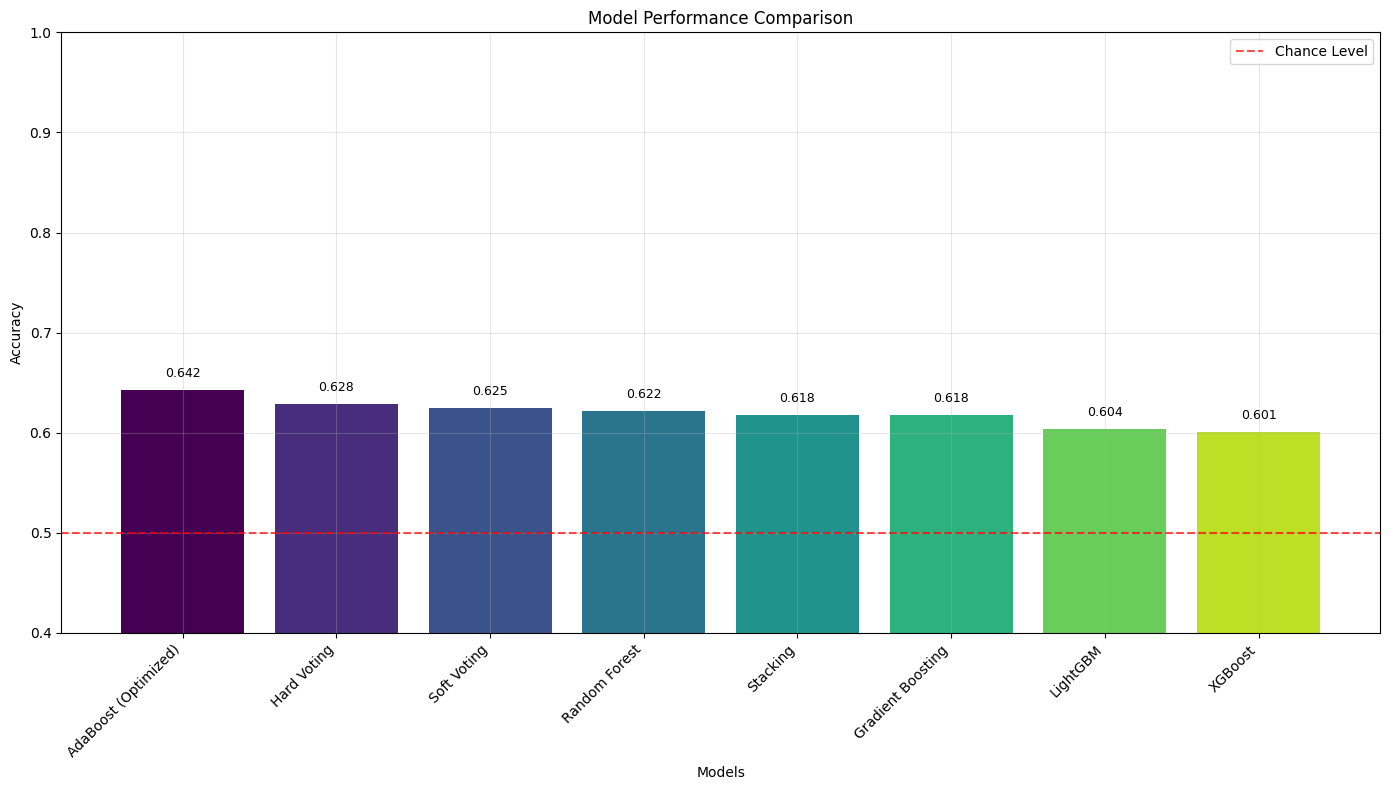

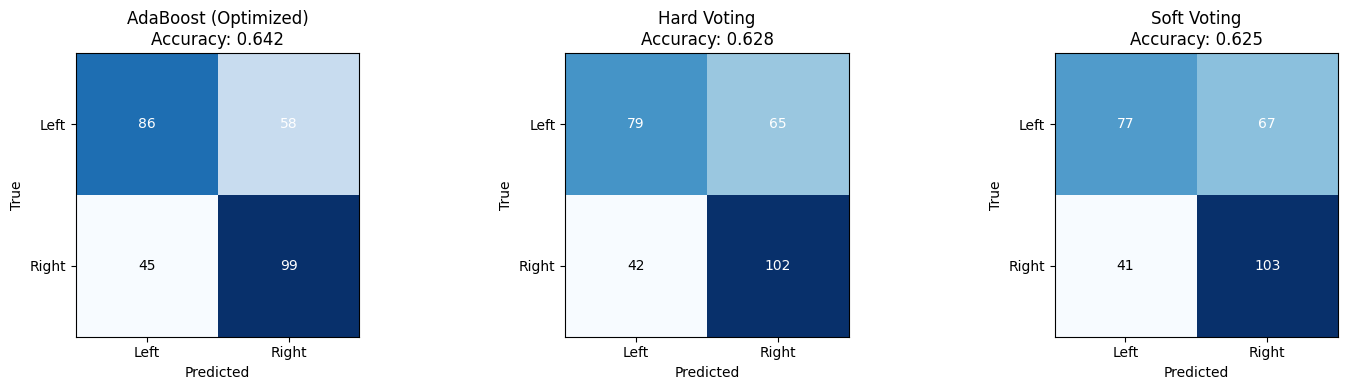

In [ ]:
# CHUNK 11: Visualization
# Bar plot comparison
plt.figure(figsize=(14, 8))
model_names = list(results.keys())
accuracies = [results[name]['accuracy'] for name in model_names]

# Sort for better visualization
sorted_indices = np.argsort(accuracies)[::-1]
model_names_sorted = [model_names[i] for i in sorted_indices]
accuracies_sorted = [accuracies[i] for i in sorted_indices]

colors = plt.cm.viridis(np.linspace(0, 0.9, len(model_names_sorted)))
bars = plt.bar(range(len(model_names_sorted)), accuracies_sorted, color=colors)
plt.axhline(y=0.5, color='red', linestyle='--', label='Chance Level', alpha=0.7)
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Performance Comparison')
plt.xticks(range(len(model_names_sorted)), model_names_sorted, rotation=45, ha='right')
plt.ylim(0.4, 1.0)

# Add value labels
for bar, acc in zip(bars, accuracies_sorted):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{acc:.3f}', ha='center', va='bottom', fontsize=9)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Confusion matrices for top 3 models
top_3_names = model_names_sorted[:3]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, name in enumerate(top_3_names):
    if name in predictions:
        y_pred = predictions[name]
    else:
        # For ensemble models
        if name == 'Hard Voting':
            y_pred = y_pred_voting_hard
        elif name == 'Soft Voting':
            y_pred = y_pred_voting_soft
        elif name == 'Stacking':
            y_pred = y_pred_stacking

    cm = confusion_matrix(y_test, y_pred)

    axes[idx].imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    axes[idx].set_title(f'{name}\nAccuracy: {results[name]["accuracy"]:.3f}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')
    axes[idx].set_xticks([0, 1])
    axes[idx].set_yticks([0, 1])
    axes[idx].set_xticklabels(['Left', 'Right'])
    axes[idx].set_yticklabels(['Left', 'Right'])

    # Add text annotations
    for i in range(2):
        for j in range(2):
            axes[idx].text(j, i, cm[i, j], ha='center', va='center',
                          color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.show()

FEATURE IMPORTANCE ANALYSIS


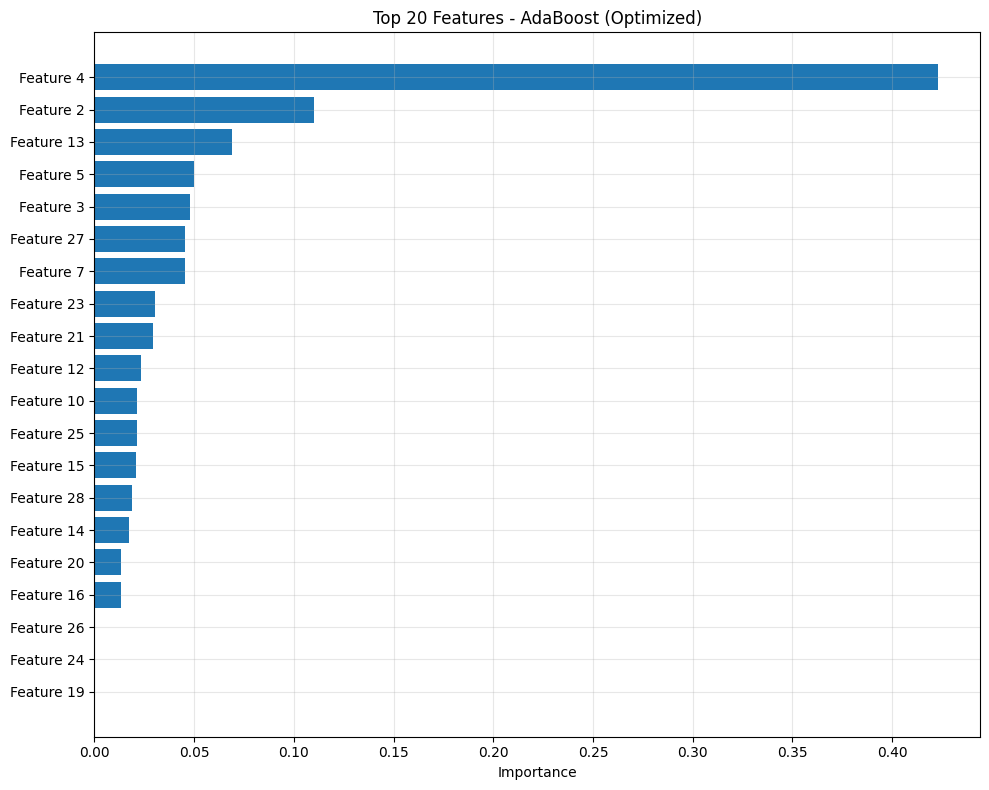


Top 5 feature indices: [ 4  2 13  5  3]


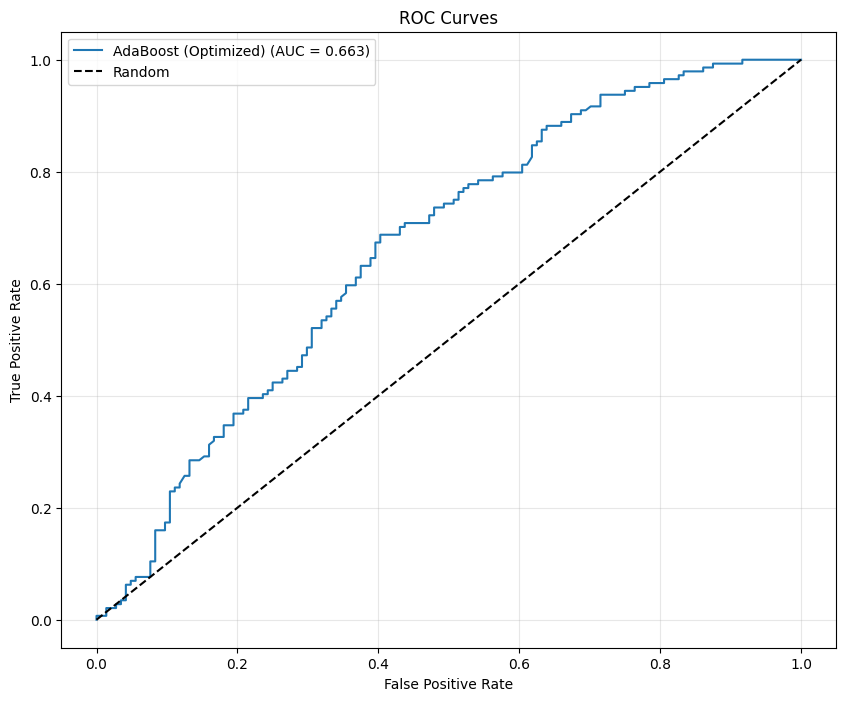


✅ Analysis complete!


In [ ]:
# CHUNK 12: Feature Importance Analysis
print("="*70)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*70)

# Get feature importance from best model
best_model = results[best_model_name]['model']

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_

    # Plot top 20 features
    top_20_idx = np.argsort(importances)[-20:]

    plt.figure(figsize=(10, 8))
    plt.barh(range(20), importances[top_20_idx])
    plt.yticks(range(20), [f'Feature {i}' for i in top_20_idx])
    plt.xlabel('Importance')
    plt.title(f'Top 20 Features - {best_model_name}')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\nTop 5 feature indices: {top_20_idx[-5:][::-1]}")
else:
    print(f"{best_model_name} does not have feature_importances_ attribute")

# ROC Curves for top models
plt.figure(figsize=(10, 8))

for name in top_3_names:
    if name in predictions:
        model = results[name]['model']
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        auc = results[name]['roc_auc'] if 'roc_auc' in results[name] else roc_auc_score(y_test, y_pred_proba)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n✅ Analysis complete!")